In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from scipy.stats import pointbiserialr, ttest_ind, mannwhitneyu, chi2_contingency

In [2]:
os.chdir("/Users/kaiping/Desktop/olist_project/data") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data'

### 1. 資料欄位過濾

In [3]:
df_translation = pd.read_csv("raw/product_category_name_translation.csv")
df_sellers     = pd.read_csv("raw/olist_sellers_dataset.csv")
df_products    = pd.read_csv("raw/olist_products_dataset.csv")
df_orders      = pd.read_csv("raw/olist_orders_dataset.csv")
df_order_reviews  = pd.read_csv("raw/olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv("raw/olist_order_payments_dataset.csv")
df_order_items    = pd.read_csv("raw/olist_order_items_dataset.csv")
df_geolocation    = pd.read_csv("raw/olist_geolocation_dataset.csv")
df_customers      = pd.read_csv("raw/olist_customers_dataset.csv")


In [4]:

# =========================
# 1. 基礎型態清理
# =========================

time_cols_orders = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in time_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

df_order_reviews["review_score"] = pd.to_numeric(
    df_order_reviews["review_score"], errors="coerce"
)

for col in ["price", "freight_value"]:
    df_order_items[col] = pd.to_numeric(df_order_items[col], errors="coerce")


# =========================
# 2. 建立 delivered 訂單口徑
# =========================

orders_base = df_orders.loc[
    df_orders["order_status"] == "delivered",
    [
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

# 加入 customer_unique_id 與 customer_state
orders_base = orders_base.merge(
    df_customers[
        [
            "customer_id",
            "customer_unique_id",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)

orders_base = orders_base.dropna(
    subset=[
        "customer_unique_id",
        "order_purchase_timestamp"
    ]
).copy()


# =========================
# 3. 設定 right censoring cutoff
# =========================

data_end = orders_base["order_purchase_timestamp"].max()
analysis_end = data_end - pd.Timedelta(days=90)

print("data_end     :", data_end)
print("analysis_end :", analysis_end)


# =========================
# 4. order_items 聚合到訂單層級
# =========================

order_items_agg = (
    df_order_items
    .groupby("order_id")
    .agg(
        item_cnt=("product_id", "size"),
        item_price_sum=("price", "sum"),
        freight_sum=("freight_value", "sum")
    )
    .reset_index()
)

# GMV = 商品金額 + 運費
order_items_agg["order_gmv"] = (
    order_items_agg["item_price_sum"] 
    + order_items_agg["freight_sum"]
)


# =========================
# 5. review 聚合到訂單層級
# =========================

order_review_agg = (
    df_order_reviews
    .groupby("order_id")
    .agg(
        review_score_mean=("review_score", "mean"),
        has_review=("review_score", lambda x: int(x.notna().any()))
    )
    .reset_index()
)


# =========================
# 6. 建立訂單層級資料
# =========================

order_level = (
    orders_base
    .merge(order_items_agg, on="order_id", how="left")
    .merge(order_review_agg, on="order_id", how="left")
)

# 交易欄位缺失補 0
for col in [
    "item_cnt",
    "item_price_sum",
    "freight_sum",
    "order_gmv"
]:
    order_level[col] = order_level[col].fillna(0)

# 沒有 review 視為 has_review = 0，但 review_score_mean 保留 NaN
order_level["has_review"] = (
    order_level["has_review"]
    .fillna(0)
    .astype(int)
)

# 配送天數
order_level["delivery_days"] = (
    order_level["order_delivered_customer_date"]
    - order_level["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# 延遲天數：實際到貨日 - 預估到貨日
order_level["delivery_delay_days"] = (
    order_level["order_delivered_customer_date"]
    - order_level["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# 小於 0 代表提早到，不算 delay，所以 clip 成 0
order_level["delivery_delay_days"] = (
    order_level["delivery_delay_days"]
    .clip(lower=0)
)

# 是否延遲
order_level["late_flag"] = (
    order_level["delivery_delay_days"].fillna(0) > 0
).astype(int)


# =========================
# 7. 建立 purchase event
#    同一顧客 + 同一 timestamp 視為同一次購買事件
# =========================

purchase_event = (
    order_level
    .groupby(
        [
            "customer_unique_id",
            "order_purchase_timestamp"
        ]
    )
    .agg(
        customer_state=("customer_state", "first"),
        first_purchase_gmv=("order_gmv", "sum"),
        first_item_cnt=("item_cnt", "sum"),
        first_review_score_mean=("review_score_mean", "mean"),
        delivery_delay_days_mean=("delivery_delay_days", "mean"),
        delivery_days_mean=("delivery_days", "mean"),
        late_flag=("late_flag", "max"),
        has_review=("has_review", "max")
    )
    .reset_index()
)


# =========================
# 8. 找出每位顧客的首購與二購
# =========================

purchase_event = purchase_event.sort_values(
    [
        "customer_unique_id",
        "order_purchase_timestamp"
    ]
).reset_index(drop=True)

purchase_event["purchase_event_rank"] = (
    purchase_event
    .groupby("customer_unique_id")
    .cumcount() + 1
)

# 首購事件
first_event = purchase_event.loc[
    purchase_event["purchase_event_rank"] == 1
].copy()

first_event = first_event.rename(
    columns={
        "order_purchase_timestamp": "first_purchase_ts"
    }
)

# 二購事件，只需要 timestamp
second_event = purchase_event.loc[
    purchase_event["purchase_event_rank"] == 2,
    [
        "customer_unique_id",
        "order_purchase_timestamp"
    ]
].copy()

second_event = second_event.rename(
    columns={
        "order_purchase_timestamp": "second_purchase_ts"
    }
)


# =========================
# 9. 合併首購與二購
# =========================

first_second_purchase_base = first_event.merge(
    second_event,
    on="customer_unique_id",
    how="left"
)


# =========================
# 10. 排除 right-censored 首購樣本
#     只保留有完整 90 天觀察期的首購顧客
# =========================

first_second_purchase_base = first_second_purchase_base.loc[
    first_second_purchase_base["first_purchase_ts"] <= analysis_end
].copy()


# =========================
# 11. 計算 days_to_2nd_purchase
# =========================

first_second_purchase_base["days_to_2nd_purchase"] = (
    first_second_purchase_base["second_purchase_ts"]
    - first_second_purchase_base["first_purchase_ts"]
).dt.total_seconds() / 86400




# =========================
# 12. 只保留指定欄位
# =========================

first_second_purchase_base = first_second_purchase_base[
    [
        "days_to_2nd_purchase",
        "second_purchase_ts",
        "first_review_score_mean",
        "delivery_delay_days_mean",
        "delivery_days_mean",
        "customer_unique_id",
        "customer_state",
        "first_purchase_ts",
        "late_flag",
        "has_review",
        "first_item_cnt",
        "first_purchase_gmv"
    ]
].copy()


# =========================
# 13. 基本檢查
# =========================

print("Shape:", first_second_purchase_base.shape)

print("\n每位顧客是否唯一：")
print(first_second_purchase_base["customer_unique_id"].is_unique)

print("\n缺失率：")
print(first_second_purchase_base.isna().mean().sort_values(ascending=False))





data_end     : 2018-08-29 15:00:00
analysis_end : 2018-05-31 15:00:00
Shape: (75320, 12)

每位顧客是否唯一：
True

缺失率：
days_to_2nd_purchase        0.973181
second_purchase_ts          0.973181
first_review_score_mean     0.007063
delivery_delay_days_mean    0.000027
delivery_days_mean          0.000027
customer_unique_id          0.000000
customer_state              0.000000
first_purchase_ts           0.000000
late_flag                   0.000000
has_review                  0.000000
first_item_cnt              0.000000
first_purchase_gmv          0.000000
dtype: float64


In [5]:
display(first_second_purchase_base.head())

,days_to_2nd_purchase,second_purchase_ts,first_review_score_mean,delivery_delay_days_mean,delivery_days_mean,customer_unique_id,customer_state,first_purchase_ts,late_flag,has_review,first_item_cnt,first_purchase_gmv
0,NaN,NaT,5.0,0.0,6.411111,0000366f3b9a7992bf8c76cfdf3221e2,SP,2018-05-10 10:56:00,0,1,1,141.90
1,NaN,NaT,4.0,0.0,3.285417,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,2018-05-07 11:11:00,0,1,1,27.19
2,NaN,NaT,3.0,0.0,25.731250,0000f46a3911fa3c0805444483337064,SC,2017-03-10 21:05:00,0,1,1,86.22
3,NaN,NaT,4.0,0.0,20.037500,0000f6ccb0745a6a4b88665a16c9f078,PA,2017-10-12 20:29:00,0,1,1,43.62
4,NaN,NaT,5.0,0.0,13.140972,0004aac84e0df4da2b147fca70cf8255,SP,2017-11-14 19:45:00,0,1,1,196.89


In [6]:

# 移除 delivery 缺失樣本


before_rows = len(first_second_purchase_base)

first_second_purchase_base = first_second_purchase_base.dropna(
    subset=[
        "delivery_delay_days_mean",
        "delivery_days_mean"
    ]
).copy()

after_rows = len(first_second_purchase_base)

print("Drop delivery missing rows:", before_rows - after_rows)

Drop delivery missing rows: 2


In [7]:
first_second_purchase_base.isna().sum()

days_to_2nd_purchase        73298
second_purchase_ts          73298
first_review_score_mean       532
delivery_delay_days_mean        0
delivery_days_mean              0
customer_unique_id              0
customer_state                  0
first_purchase_ts               0
late_flag                       0
has_review                      0
first_item_cnt                  0
first_purchase_gmv              0
dtype: int64

In [8]:
# 建立y label (90天內二購1 ,反之0) 
analysis_df = first_second_purchase_base.copy()

# 建立目標變數：90 天內是否二購
analysis_df["purchase_2nd_within_90d"] = (
    analysis_df["days_to_2nd_purchase"].notna()
    & (analysis_df["days_to_2nd_purchase"] <= 90)
).astype(int)
analysis_df

,days_to_2nd_purchase,second_purchase_ts,first_review_score_mean,delivery_delay_days_mean,delivery_days_mean,customer_unique_id,customer_state,first_purchase_ts,late_flag,has_review,first_item_cnt,first_purchase_gmv,purchase_2nd_within_90d
0,NaN,NaT,5.0,0.0,6.411111,0000366f3b9a7992bf8c76cfdf3221e2,SP,2018-05-10 10:56:00,0,1,1,141.90,0
1,NaN,NaT,4.0,0.0,3.285417,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,2018-05-07 11:11:00,0,1,1,27.19,0
2,NaN,NaT,3.0,0.0,25.731250,0000f46a3911fa3c0805444483337064,SC,2017-03-10 21:05:00,0,1,1,86.22,0
3,NaN,NaT,4.0,0.0,20.037500,0000f6ccb0745a6a4b88665a16c9f078,PA,2017-10-12 20:29:00,0,1,1,43.62,0
4,NaN,NaT,5.0,0.0,13.140972,0004aac84e0df4da2b147fca70cf8255,SP,2017-11-14 19:45:00,0,1,1,196.89,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,NaN,NaT,5.0,0.0,27.515278,fffcf5a5ff07b0908bd4e2dbc735a684,PE,2017-06-08 21:00:00,0,1,2,2067.42,0
93354,NaN,NaT,4.0,0.0,30.097917,fffea47cd6d3cc0a88bd621562a9d061,BA,2017-12-10 20:07:00,0,1,1,84.58,0
93355,NaN,NaT,5.0,0.0,14.872222,ffff371b4d645b6ecea244b27531430a,MT,2017-02-07 15:49:00,0,1,1,112.46,0
93356,NaN,NaT,5.0,0.0,11.859028,ffff5962728ec6157033ef9805bacc48,ES,2018-05-02 15:17:00,0,1,1,133.69,0


### 2. overall分析

In [9]:
# 目標變數分佈

target_summary = (
    analysis_df["purchase_2nd_within_90d"]
    .value_counts()
    .rename_axis("purchase_2nd_within_90d")
    .reset_index(name="customer_count")
)

target_summary["rate_pct"] = (
    target_summary["customer_count"] / target_summary["customer_count"].sum() * 100
)

display(target_summary)


,purchase_2nd_within_90d,customer_count,rate_pct
0,0,74206,98.523593
1,1,1112,1.476407


In [10]:
# =========================
# 2. 數值變數 vs 目標變數
# =========================
target_col = "purchase_2nd_within_90d"
numeric_features = [
    "first_review_score_mean",
    "delivery_delay_days_mean",
    "delivery_days_mean",
    "first_item_cnt",
    "first_purchase_gmv"
]

numeric_result = []

for col in numeric_features:
    temp = analysis_df[[col, target_col]].dropna().copy()
    
    group0 = temp.loc[temp[target_col] == 0, col]
    group1 = temp.loc[temp[target_col] == 1, col]
    
    mean0 = group0.mean()
    mean1 = group1.mean()
    median0 = group0.median()
    median1 = group1.median()
    
    std0 = group0.std()
    std1 = group1.std()
    
    pooled_std = np.sqrt((std0**2 + std1**2) / 2)
    
    if pooled_std == 0 or np.isnan(pooled_std):
        standardized_diff = np.nan
    else:
        standardized_diff = (mean1 - mean0) / pooled_std
    
    try:
        corr, p_value = pointbiserialr(temp[target_col], temp[col])
    except:
        corr, p_value = np.nan, np.nan
    
    numeric_result.append({
        "feature": col,
        "n": len(temp),
        "mean_y0": mean0,
        "mean_y1": mean1,
        "median_y0": median0,
        "median_y1": median1,
        "mean_diff_y1_minus_y0": mean1 - mean0,
        "standardized_diff": standardized_diff,
        "point_biserial_corr": corr,
        "p_value": p_value
    })

numeric_assoc_df = pd.DataFrame(numeric_result)

numeric_assoc_df = numeric_assoc_df.sort_values(
    by="standardized_diff",
    key=lambda x: x.abs(),
    ascending=False
)

display(numeric_assoc_df)

,feature,n,mean_y0,mean_y1,median_y0,median_y1,mean_diff_y1_minus_y0,standardized_diff,point_biserial_corr,p_value
3,first_item_cnt,75318,1.150028,1.271583,1.000000,1.000000,0.121554,0.166868,0.026317,5.062478e-13
2,delivery_days_mean,75318,13.528542,12.225758,11.199306,10.512847,-1.302785,-0.142922,-0.015650,1.745738e-05
0,first_review_score_mean,74786,4.114127,4.270532,5.000000,5.000000,0.156406,0.124386,0.014449,7.768560e-05
1,delivery_delay_days_mean,75318,0.904488,0.582966,0.000000,0.000000,-0.321523,-0.074964,-0.007439,4.118455e-02
4,first_purchase_gmv,75318,160.852637,154.502014,105.590000,104.675000,-6.350622,-0.031925,-0.003499,3.369583e-01


首購體驗與 90 天內二購存在方向合理但效果偏弱的關聯。二購顧客通常有略高的首購評分、略短的配送時間、略低的配送延遲，
但標準化差異不大，表示單一體驗變數不足以強力解釋二購行為。這些變數更適合作為二購傾向模型中的輔助特徵，而不是單獨作為決策依據。

### 3. 顧客體驗對於二購分析

### 3.1 體驗衍生變數定義

將首購體驗相關欄位轉換成較容易分組比較的變數，用於觀察不同體驗條件下，90 天內二購率是否存在差異。



| 變數名稱 | 建立規則 | 商業意義 |
|---|---|---|
| `low_review_flag` | 首購評分 `<= 3` 設為 1，否則為 0 | 是否有低評分體驗 |
| `high_review_flag` | 首購評分 `= 5` 設為 1，否則為 0 | 是否有高滿意度體驗 |
| `severe_delay_flag` | 配送延遲天數 `>= 7` 設為 1，否則為 0 | 是否發生嚴重延遲 |
| `fast_delivery_flag` | 配送天數 `<= 7` 設為 1，否則為 0 | 是否快速送達 |
| `delivery_delay_bin` | 將延遲分為 `未延遲`、`延遲1-3天`、`延遲4-7天`、`延遲8天以上` | 比較不同延遲程度的二購率 |
| `delivery_days_bin` | 將配送天數分為 `7天內`、`8-14天`、`15-21天`、`22天以上` | 比較不同配送速度的二購率 |



In [11]:
target_col = "purchase_2nd_within_90d"

exp_df = analysis_df.copy()

# 低評分：1~3 分視為體驗不佳
exp_df["low_review_flag"] = np.where(
    exp_df["first_review_score_mean"].notna() & 
    (exp_df["first_review_score_mean"] <= 3),
    1,
    0
)

# 高評分：5 分視為非常滿意
exp_df["high_review_flag"] = np.where(
    exp_df["first_review_score_mean"].notna() & 
    (exp_df["first_review_score_mean"] >= 5),
    1,
    0
)

# 嚴重延遲：延遲 7 天以上
exp_df["severe_delay_flag"] = np.where(
    exp_df["delivery_delay_days_mean"] >= 7,
    1,
    0
)

# 快速配送：7 天內送達
exp_df["fast_delivery_flag"] = np.where(
    exp_df["delivery_days_mean"] <= 7,
    1,
    0
)

# 延遲天數分箱
exp_df["delivery_delay_bin"] = pd.cut(
    exp_df["delivery_delay_days_mean"],
    bins=[-0.01, 0, 3, 7, np.inf],
    labels=["未延遲", "延遲1-3天", "延遲4-7天", "延遲8天以上"]
)

# 配送天數分箱
exp_df["delivery_days_mean_bin"] = pd.cut(
    exp_df["delivery_days_mean"],
    bins=[0, 7, 14, 21, np.inf],
    labels=[
        "0-7天（含7）",
        ">7-14天（含14）",
        ">14-21天（含21）",
        ">21天"
    ],
    include_lowest=True
)

print("整體 90 天內二購率：")
overall_rate = exp_df[target_col].mean()
print(f"{overall_rate:.4%}")

整體 90 天內二購率：
1.4764%


In [12]:
exp_df.head()

,days_to_2nd_purchase,second_purchase_ts,first_review_score_mean,delivery_delay_days_mean,delivery_days_mean,customer_unique_id,customer_state,first_purchase_ts,late_flag,has_review,first_item_cnt,first_purchase_gmv,purchase_2nd_within_90d,low_review_flag,high_review_flag,severe_delay_flag,fast_delivery_flag,delivery_delay_bin,delivery_days_mean_bin
0,NaN,NaT,5.0,0.0,6.411111,0000366f3b9a7992bf8c76cfdf3221e2,SP,2018-05-10 10:56:00,0,1,1,141.90,0,0,1,0,1,未延遲,0-7天（含7）
1,NaN,NaT,4.0,0.0,3.285417,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,2018-05-07 11:11:00,0,1,1,27.19,0,0,0,0,1,未延遲,0-7天（含7）
2,NaN,NaT,3.0,0.0,25.731250,0000f46a3911fa3c0805444483337064,SC,2017-03-10 21:05:00,0,1,1,86.22,0,1,0,0,0,未延遲,>21天
3,NaN,NaT,4.0,0.0,20.037500,0000f6ccb0745a6a4b88665a16c9f078,PA,2017-10-12 20:29:00,0,1,1,43.62,0,0,0,0,0,未延遲,>14-21天（含21）
4,NaN,NaT,5.0,0.0,13.140972,0004aac84e0df4da2b147fca70cf8255,SP,2017-11-14 19:45:00,0,1,1,196.89,0,0,1,0,0,未延遲,>7-14天（含14）


In [13]:
# 3.1低評分顧客的二購率是否低於非低評分顧客？
target_col = "purchase_2nd_within_90d"

low_review_summary = (
    exp_df
    .groupby("low_review_flag")
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

# 標籤轉換
low_review_summary["group"] = low_review_summary["low_review_flag"].map({
    0: "非低評分顧客",
    1: "低評分顧客"
})

# 整理欄位
low_review_summary = low_review_summary[
    [
        "group",
        "customer_count",
        "second_purchase_count",
        "second_purchase_rate_pct"
    ]
]

# 四捨五入
low_review_summary["second_purchase_rate_pct"] = (
    low_review_summary["second_purchase_rate_pct"].round(2)
)

display(low_review_summary)

,group,customer_count,second_purchase_count,second_purchase_rate_pct
0,非低評分顧客,58736,913,1.55
1,低評分顧客,16582,199,1.20


低評分顧客的二購率低於非低評分顧客。低評分顧客的二購率約比非低評分顧客低 22.5%。

這代表首購低評分可能與較低的二購率有關，方向符合商業直覺：若顧客在首購後給出較低評分，可能表示其購物、商品或配送體驗不佳，因此後續再次購買的意願較低。


In [14]:

# 3.2 配送天數分組與 90 天內二購率的關聯分析

target_col = "purchase_2nd_within_90d"

exp_df["delivery_days_bin"] = pd.cut(
    exp_df["delivery_days_mean"],
    bins=[0, 7, 14, 21, np.inf],
    labels=[
        "0-7天（含7）",
        ">7-14天（含14）",
        ">14-21天（含21）",
        ">21天"
    ],
    include_lowest=True
)

# 依照配送天數區間分組，計算顧客數、二購人數、二購率
delivery_days_summary = (
    exp_df
    .groupby("delivery_days_bin", observed=False)
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

# 欄位重新命名
delivery_days_summary = delivery_days_summary.rename(
    columns={"delivery_days_bin": "group"}
)

# 四捨五入
delivery_days_summary["second_purchase_rate_pct"] = (
    delivery_days_summary["second_purchase_rate_pct"].round(2)
)

display(delivery_days_summary)

,group,customer_count,second_purchase_count,second_purchase_rate_pct
0,0-7天（含7）,17179,285,1.66
1,>7-14天（含14）,31089,475,1.53
2,>14-21天（含21）,15559,229,1.47
3,>21天,11491,123,1.07


從描述統計結果來看，首購平均配送天數越短的顧客，其 90 天內二購率越高。配送天數在 0-7 天內的顧客二購率為 1.66%，而配送天數超過 21 天的顧客二購率下降至 1.07%。

此結果呈現出較清楚的遞減趨勢，代表首購實際配送天數與二購率之間存在負向關聯。換言之，顧客等待商品的時間越長，後續再次購買的比例越低。

相較於「是否延遲」或「延遲嚴重程度」，實際配送天數 `delivery_days_mean` 更能直接反映顧客的等待體驗，因此在解釋二購行為時具有較高的商業可解釋性。

不過，由於整體二購率本身偏低，各組之間的絕對差距仍不算大，因此配送天數應被視為重要但非唯一的二購訊號，後續仍需結合評分、地區、購買金額與商品類別等變數共同分析。

In [15]:
# 3.3 是否延遲與 90 天內二購率的關聯分析
# 定義：delivery_delay_days_mean > 0 視為有延遲

target_col = "purchase_2nd_within_90d"


# 確保 late_flag 型態一致
exp_df["late_flag"] = exp_df["late_flag"].astype(int)

# 整體二購率
overall_rate_pct = exp_df[target_col].mean() * 100

# 依照是否延遲分組，計算顧客數、二購人數、二購率
late_summary = (
    exp_df
    .groupby("late_flag")
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

# 標籤轉換
late_summary["group"] = late_summary["late_flag"].map({
    0: "未延遲",
    1: "有延遲"
})


# 整理欄位
late_summary = late_summary[
    [
        "group",
        "customer_count",
        "second_purchase_count",
        "second_purchase_rate_pct"
    ]
]

# 四捨五入
late_summary["second_purchase_rate_pct"] = late_summary["second_purchase_rate_pct"].round(2)

display(late_summary)

,group,customer_count,second_purchase_count,second_purchase_rate_pct
0,未延遲,68678,1034,1.51
1,有延遲,6640,78,1.17


In [16]:

# 3.3是否嚴重延遲與 90 天內二購率的關聯分析 (配送延遲天數>=7)


target_col = "purchase_2nd_within_90d"

# 建立嚴重延遲 flag
# delivery_delay_days_mean >= 7 視為嚴重延遲
exp_df["severe_delay_flag"] = np.where(
    exp_df["delivery_delay_days_mean"] >= 7,
    1,
    0
)

# 依照是否嚴重延遲分組
severe_delay_summary = (
    exp_df
    .groupby("severe_delay_flag")
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

# 標籤轉換
severe_delay_summary["group"] = severe_delay_summary["severe_delay_flag"].map({
    0: "未嚴重延遲",
    1: "嚴重延遲(配送延遲天數>=7)"
})

# 整理欄位
severe_delay_summary = severe_delay_summary[
    [
        "group",
        "customer_count",
        "second_purchase_count",
        "second_purchase_rate_pct"
    ]
]

# 四捨五入
severe_delay_summary["second_purchase_rate_pct"] = (
    severe_delay_summary["second_purchase_rate_pct"].round(2)
)

display(severe_delay_summary)

,group,customer_count,second_purchase_count,second_purchase_rate_pct
0,未嚴重延遲,72276,1075,1.49
1,嚴重延遲(配送延遲天數>=7),3042,37,1.22


In [17]:

# 3.4 延遲嚴重程度與 90 天內二購率的關聯分析


target_col = "purchase_2nd_within_90d"

# 建立延遲天數分組
# pd.cut 預設為右閉區間：
# 未延遲：delivery_delay_days_mean <= 0
# >0-3天（含3）：0 < delay <= 3
# >3-7天（含7）：3 < delay <= 7
# >7天：delay > 7

exp_df["delivery_delay_bin"] = pd.cut(
    exp_df["delivery_delay_days_mean"],
    bins=[-np.inf, 0, 3, 7, np.inf],
    labels=[
        "未延遲",
        ">0-3天（含3）",
        ">3-7天（含7）",
        ">7天"
    ],
    include_lowest=True
)

# 依照延遲程度分組
delivery_delay_summary = (
    exp_df
    .groupby("delivery_delay_bin", observed=False)
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

# 欄位重新命名
delivery_delay_summary = delivery_delay_summary.rename(
    columns={"delivery_delay_bin": "group"}
)

# 四捨五入
delivery_delay_summary["second_purchase_rate_pct"] = (
    delivery_delay_summary["second_purchase_rate_pct"].round(2)
)

display(delivery_delay_summary)

,group,customer_count,second_purchase_count,second_purchase_rate_pct
0,未延遲,68678,1034,1.51
1,>0-3天（含3）,2040,27,1.32
2,>3-7天（含7）,1558,14,0.90
3,>7天,3042,37,1.22




從描述統計結果來看，未延遲顧客的 90 天內二購率為 1.51%，高於所有延遲組。延遲 0-3 天顧客的二購率為 1.32%，延遲 3-7 天顧客的二購率為 0.90%，延遲 7 天以上顧客的二購率為 1.22%。

此結果顯示，配送延遲與較低的二購率存在負向關聯，方向上符合商業直覺：若顧客首購時發生配送延遲，後續再次購買的意願可能較低。

不過，延遲程度與二購率並未呈現完全單調遞減關係。特別是延遲 7 天以上顧客的二購率高於延遲 3-7 天顧客，代表延遲嚴重程度本身的解釋力有限，可能受到商品類別、地區、物流預期或顧客結構差異影響。

因此，本節結論為：配送延遲可能是負向二購訊號，但其解釋力弱於實際配送天數 `delivery_days_mean`，較適合作為後續模型中的輔助特徵，而非單獨作為判斷二購機率的主要依據。

In [18]:

# 3.5 快速送達與 90 天內二購率的關聯分析


target_col = "purchase_2nd_within_90d"

# 建立快速送達 flag
# delivery_days_mean <= 7 視為快速送達
exp_df["fast_delivery_flag"] = np.where(
    exp_df["delivery_days_mean"] <= 7,
    1,
    0
)

# 依照是否快速送達分組
fast_delivery_summary = (
    exp_df
    .groupby("fast_delivery_flag")
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

# 標籤轉換
fast_delivery_summary["group"] = fast_delivery_summary["fast_delivery_flag"].map({
    0: "非快速送達",
    1: "快速送達"
})

# 整理欄位
fast_delivery_summary = fast_delivery_summary[
    [
        "group",
        "customer_count",
        "second_purchase_count",
        "second_purchase_rate_pct"
    ]
]

# 四捨五入
fast_delivery_summary["second_purchase_rate_pct"] = (
    fast_delivery_summary["second_purchase_rate_pct"].round(2)
)

display(fast_delivery_summary)

,group,customer_count,second_purchase_count,second_purchase_rate_pct
0,非快速送達,58139,827,1.42
1,快速送達,17179,285,1.66


從描述統計結果來看，非快速送達顧客的 90 天內二購率為 1.42%，而快速送達顧客的 90 天內二購率為 1.66%。快速送達顧客的二購率較高，差距約為 0.24 個百分點。

此結果顯示，快速送達與較高的二購率存在正向關聯，方向上符合商業直覺：若顧客在首購時能較快收到商品，可能對平台形成較好的購物體驗，進而提高後續再次購買的可能性。

不過，由於兩組二購率的絕對差距不大，快速送達不應被視為單獨判斷二購的強力因素，而較適合作為後續二購傾向模型中的輔助訊號。

In [19]:
# ============================================================
# 3.6 配送天數分組 × 評分體驗 對 90 天內二購率的交叉分析
# 排除無評論
# 評分規則：
# 0-4 分：低評分
# >4-5 分：高評分
# ============================================================
target_col = "purchase_2nd_within_90d"

# 1. 建立配送天數分組
delivery_order = [
    "0-7天（含7）",
    ">7-14天（含14）",
    ">14-21天（含21）",
    ">21天"
]

exp_df["delivery_days_bin"] = pd.cut(
    exp_df["delivery_days_mean"],
    bins=[0, 7, 14, 21, np.inf],
    labels=delivery_order,
    include_lowest=True
)

# 2. 建立評分分組：先排除無評論
cross_df = exp_df[exp_df["first_review_score_mean"].notna()].copy()

cross_df["review_group"] = np.where(
    cross_df["first_review_score_mean"] <= 4,
    "0-4分低評分",
    ">4-5分高評分"
)

# 3. 交叉分組計算二購率
delivery_review_cross = (
    cross_df
    .groupby(["delivery_days_bin", "review_group"], observed=True)
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

delivery_review_cross = delivery_review_cross.rename(
    columns={"delivery_days_bin": "delivery_days_group"}
)

delivery_review_cross["second_purchase_rate_pct"] = (
    delivery_review_cross["second_purchase_rate_pct"].round(2)
)

display(delivery_review_cross)



,delivery_days_group,review_group,customer_count,second_purchase_count,second_purchase_rate_pct
0,0-7天（含7）,0-4分低評分,5466,93,1.70
1,0-7天（含7）,>4-5分高評分,11628,191,1.64
2,>7-14天（含14）,0-4分低評分,11456,148,1.29
3,>7-14天（含14）,>4-5分高評分,19462,326,1.68
4,>14-21天（含21）,0-4分低評分,6886,84,1.22
5,>14-21天（含21）,>4-5分高評分,8564,145,1.69
6,>21天,0-4分低評分,7756,78,1.01
7,>21天,>4-5分高評分,3568,43,1.21


In [20]:

# macOS 常見中文字型
plt.rcParams["font.sans-serif"] = [
    "PingFang TC",
    "Heiti TC",
    "Arial Unicode MS",
    "Microsoft JhengHei",
    "Noto Sans CJK TC"
]

# 避免負號顯示錯誤
plt.rcParams["axes.unicode_minus"] = False

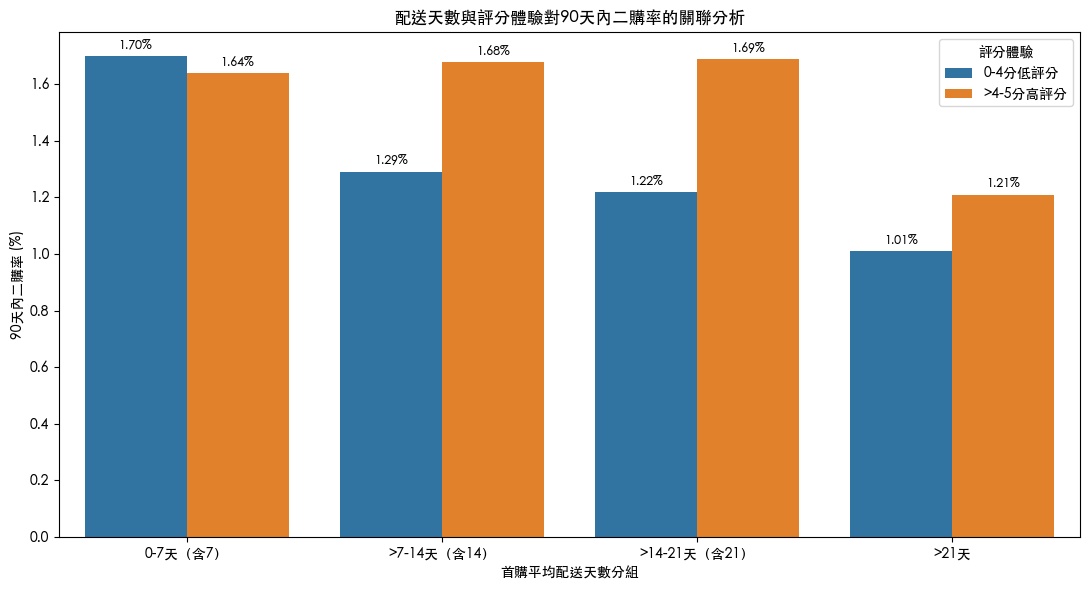

In [21]:

# 畫圖：配送天數 × 評分體驗 對 90 天內二購率

# 設定中文字型
plt.rcParams["font.sans-serif"] = [
    "PingFang TC",
    "Heiti TC",
    "Arial Unicode MS",
    "Microsoft JhengHei",
    "Noto Sans CJK TC"
]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=delivery_review_cross,
    x="delivery_days_group",
    y="second_purchase_rate_pct",
    hue="review_group",
    order=delivery_order,
    hue_order=["0-4分低評分", ">4-5分高評分"]
)

plt.title("配送天數與評分體驗對90天內二購率的關聯分析")
plt.xlabel("首購平均配送天數分組")
plt.ylabel("90天內二購率 (%)")
plt.legend(title="評分體驗")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


從交叉分析結果來看，配送天數與評分體驗之間存在一定的組合關聯。整體而言，低評分組的二購率會隨著配送天數變長而明顯下降，從 0-7 天區間的 1.70% 下降至超過 21 天區間的 1.01%。

相較之下，高評分組在 7-21 天區間的二購率相對穩定，約維持在 1.64% 至 1.69% 之間，僅在配送超過 21 天後下降至 1.21%。這表示高評分體驗可能對較長配送時間具有一定緩衝效果。

因此，本分析顯示，單一體驗變數的解釋力有限，但當「配送天數」與「評分體驗」交叉觀察時，可以看到較明顯的體驗組合差異。其中，「低評分 + 長配送時間」是二購率最低的組合，可能代表負向首購體驗會降低顧客進入二購階段的可能性。
低評分組對配送天數更敏感；當低評分與長配送同時出現時，二購率最低。這比單獨看評分或單獨看配送天數更有商業解釋力。

### 4. 地區變數與90天內二購率關聯

In [22]:

# 4.1州別與 90 天內二購率的關聯分析


target_col = "purchase_2nd_within_90d"

# 1. 依州別計算顧客數、二購人數、二購率
state_summary = (
    exp_df
    .groupby("customer_state")
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

state_summary["second_purchase_rate_pct"] = (
    state_summary["second_purchase_rate_pct"].round(2)
)

# 2. 依二購率由高到低排序
state_summary = state_summary.sort_values(
    by="second_purchase_rate_pct",
    ascending=False
)

display(state_summary)

,customer_state,customer_count,second_purchase_count,second_purchase_rate_pct
7,ES,1587,35,2.21
12,MT,714,14,1.96
3,AP,56,1,1.79
25,SP,30790,496,1.61
16,PI,385,6,1.56
20,RO,195,3,1.54
0,AC,66,1,1.52
4,BA,2573,39,1.52
8,GO,1576,24,1.52
18,RJ,9864,149,1.51


In [23]:
# 排除樣本低於500人的州別

min_n = 500

state_summary_filtered = state_summary[
    state_summary["customer_count"] >= min_n
].copy()

display(state_summary_filtered)

,customer_state,customer_count,second_purchase_count,second_purchase_rate_pct
7,ES,1587,35,2.21
12,MT,714,14,1.96
25,SP,30790,496,1.61
4,BA,2573,39,1.52
8,GO,1576,24,1.52
18,RJ,9864,149,1.51
10,MG,9004,127,1.41
22,RS,4288,60,1.40
6,DF,1576,21,1.33
11,MS,551,7,1.27


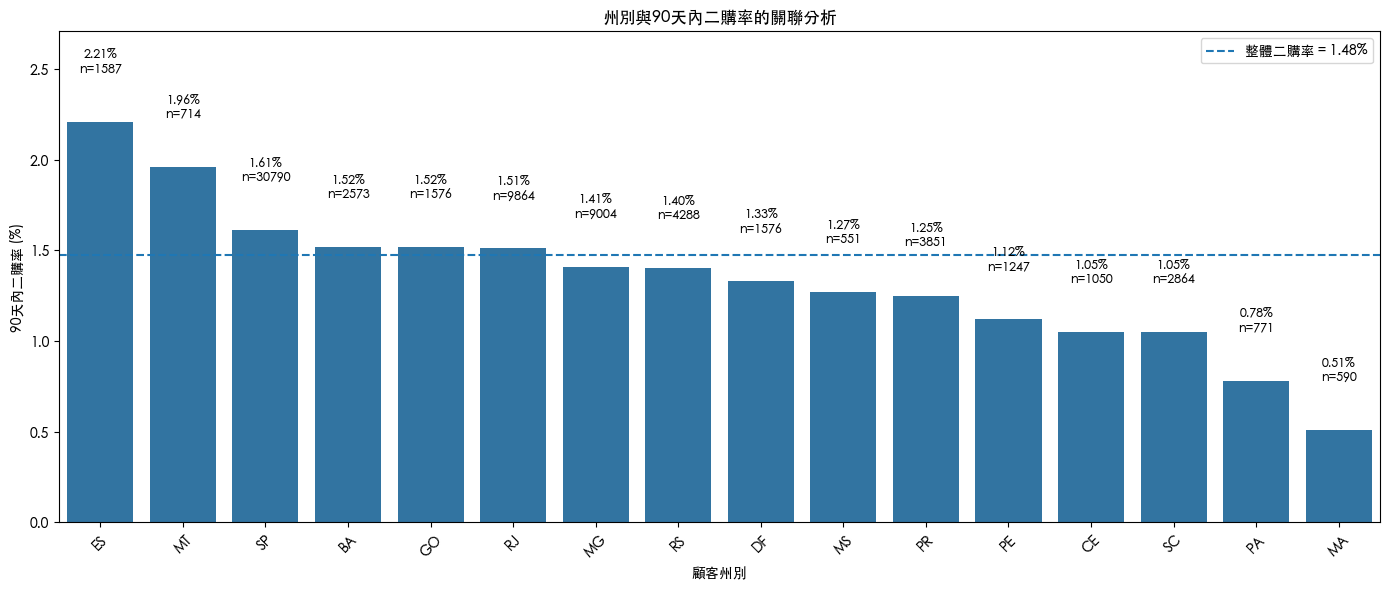

In [24]:
# 州別二購率視覺化：加入樣本數 n

overall_rate = exp_df[target_col].mean() * 100

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=state_summary_filtered,
    x="customer_state",
    y="second_purchase_rate_pct",
    order=state_summary_filtered["customer_state"]
)

plt.axhline(
    overall_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"整體二購率 = {overall_rate:.2f}%"
)

# 在 bar 上標註二購率與樣本數
for patch, row in zip(ax.patches, state_summary_filtered.itertuples()):
    height = patch.get_height()
    
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height + 0.26,
        f"{row.second_purchase_rate_pct:.2f}%\nn={row.customer_count}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("州別與90天內二購率的關聯分析")
plt.xlabel("顧客州別")
plt.ylabel("90天內二購率 (%)")
plt.legend()
plt.xticks(rotation=45)

# 避免文字被切掉
plt.ylim(0, state_summary_filtered["second_purchase_rate_pct"].max() + 0.5)

plt.tight_layout()
plt.show()



從描述統計結果來看，不同州別的 90 天內二購率存在一定差異。整體二購率約為 1.48%，其中 ES、MT、SP、BA、GO、RJ 等州別高於整體平均，而 MA、PA、SC、CE、PE 等州別低於整體平均。

其中，SP 的二購率為 1.61%，且樣本數達 30,790，代表該州別的結果較具穩定性與參考價值。相較之下，ES 與 MT 雖然二購率較高，但樣本數相對較小，因此解讀時需避免過度推論。

整體而言，州別與二購率之間存在關聯，可能反映不同地區在物流效率、顧客結構、商品供給或消費習慣上的差異。不過，州別本身不應被直接解讀為造成二購率差異的原因，而較適合作為後續模型中的地區特徵或分群變數。

因此，本節結論為：州別具有一定的二購區辨訊號，尤其在樣本數充足的州別中更具參考價值。

### 5. 購買強度與90天內二購率關聯

In [25]:

# 5.1 購買強度與 90 天內二購率的關聯分析





target_col = "purchase_2nd_within_90d"

# ------------------------------------------------------------
# 1. first_item_cnt：首購商品件數分組
# ------------------------------------------------------------

exp_df["first_item_cnt_group"] = pd.cut(
    exp_df["first_item_cnt"],
    bins=[0, 1, 2, np.inf],
    labels=["1件", "2件", "3件以上"],
    include_lowest=True
)

item_cnt_summary = (
    exp_df
    .groupby("first_item_cnt_group", observed=False)
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

item_cnt_summary["second_purchase_rate_pct"] = (
    item_cnt_summary["second_purchase_rate_pct"].round(2)
)

display(item_cnt_summary)


# ------------------------------------------------------------
# 2. first_purchase_gmv：首購金額分成四分位數
# ------------------------------------------------------------

exp_df["first_purchase_gmv_group"] = pd.qcut(
    exp_df["first_purchase_gmv"],
    q=4,
    labels=["Q1低金額", "Q2中低金額", "Q3中高金額", "Q4高金額"],
    duplicates="drop"
)

gmv_summary = (
    exp_df
    .groupby("first_purchase_gmv_group", observed=False)
    .agg(
        customer_count=(target_col, "size"),
        second_purchase_count=(target_col, "sum"),
        second_purchase_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

gmv_summary["second_purchase_rate_pct"] = (
    gmv_summary["second_purchase_rate_pct"].round(2)
)

display(gmv_summary)

,first_item_cnt_group,customer_count,second_purchase_count,second_purchase_rate_pct
0,1件,67271,933,1.39
1,2件,6181,123,1.99
2,3件以上,1866,56,3.00


,first_purchase_gmv_group,customer_count,second_purchase_count,second_purchase_rate_pct
0,Q1低金額,18830,296,1.57
1,Q2中低金額,18829,271,1.44
2,Q3中高金額,18830,257,1.36
3,Q4高金額,18829,288,1.53


從描述統計結果來看，首購商品件數 `first_item_cnt` 與 90 天內二購率呈現明顯正向關聯。首購 1 件商品的顧客二購率為 1.39%，首購 2 件商品的顧客二購率提升至 1.99%，而首購 3 件以上商品的顧客二購率達 3.00%。這表示首購件數越多，顧客後續進入二購的比例越高。

相較之下，首購金額 `first_purchase_gmv` 與二購率之間沒有明顯穩定趨勢。四個金額分位組的二購率約落在 1.36% 至 1.57% 之間，並未呈現金額越高、二購率越高的現象。

因此，本節結論為：首購商品件數可能是較有解釋力的購買強度訊號，而首購金額本身對二購率的區辨能力較弱。這可能是因為商品件數較能反映顧客的需求廣度與購買參與度，而首購金額容易受到商品單價影響，不一定代表顧客有較高再購傾向。


### 總結
本節以描述統計方式分析首購體驗、地區與購買強度變數和 90 天內二購率之間的關聯。整體而言，平台 90 天內二購率僅約 1.48%，顯示首購顧客轉化為二購顧客的比例偏低。

分析結果顯示，首購商品件數與二購率呈現最明顯的正向關聯。首購 1 件商品的顧客二購率為 1.39%，首購 2 件商品提升至 1.99%，首購 3 件以上則達到 3.00%。這代表首購購買強度，特別是商品件數，可能是辨識高二購潛力顧客的重要訊號。

在體驗變數方面，首購平均配送天數 `delivery_days_mean` 具有較清楚的負向關聯。配送天數在 0-7 天內的顧客二購率為 1.66%，而配送超過 21 天的顧客二購率下降至 1.07%。相較於是否延遲，實際配送天數更能直接反映顧客等待體驗，因此具有較高的商業解釋性。

此外，評分與配送天數的交叉分析顯示，低評分組對配送天數更敏感。當低評分與長配送時間同時出現時，二購率最低，代表負向首購體驗組合可能與較低二購率有關。

州別分析也顯示不同地區的二購率存在差異，可能反映物流效率、商品供給與顧客結構上的差異。因此，州別可作為後續模型中的地區特徵，但不應被直接解讀為造成二購率差異的因果因素。

整體而言，本節結果顯示，`first_item_cnt`、`delivery_days_mean`、`customer_state`、`review_score` 相關變數具備一定二購訊號，適合納入後續二購傾向模型；而 `first_purchase_gmv` 的關聯較弱，較不適合單獨作為二購判斷依據。